# Neural Networks 


## Activate access to Google Drive 

In [1]:
# ##### If using Google Colab -- Uncomment following lines ######

# from google.colab import drive
# drive.mount('/content/gdrive')

## Import Files and Modules

In [ ]:
import json
import random
import sys

import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# from tensorflow.keras.datasets import mnist

import matplotlib.pyplot as plt


## Load MNIST Dataset

In [4]:
## Load the MNIST dataset
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)  

## Renormalize the pixels. Note the Pixels values in MNIST range from 0 to 255 (8-bit grayscale: 0 = black, 255 = white), and dividing by 255 rescales them to the [0, 1] range.
X = X / 255.0 
## Convert the labels into integers.
y = y.astype(int)

## Split the data into train (80%) and test (20%) split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

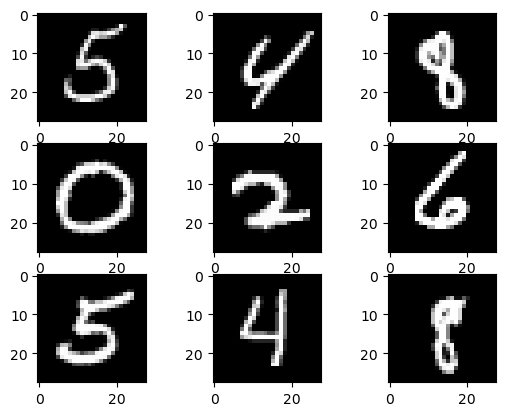

In [11]:
for i in range(9):  
    plt.subplot(330 + 1 + i)
    plt.imshow(np.reshape(X_train[i], (28,28)), cmap=plt.get_cmap('gray'))
plt.show()

In [ ]:
class CrossEntropyCost:
    """Categorical cross-entropy, paired with softmax output."""
    @staticmethod
    def loss(a, y):
        return -np.sum(y * np.log(a + 1e-9)) / y.shape[0]
    # np.sum(np.nan_to_num(-y*np.log(a)-(1-y)*np.log(1-a)))

    @staticmethod
    def delta(a, y):
        return (a - y) / y.shape[0]      # softmax + CE shortcut


class MSECost:
    """Mean squared error, paired with softmax output here."""
    @staticmethod
    def loss(a, y):
        return np.sum((a - y)**2) / (2 * y.shape[0])

    @staticmethod
    def delta(a, y):
        return (a - y) / y.shape[0]      # assumes linear/identity output

In [18]:
class NeuralNet:

    def __init__(self, input_size = 784, ouptut_size = 10, layers=[64], lr=0.1, activation='relu', cost=CrossEntropyCost):
        """ Initialize the class:
            -- layers   : a list that contains the number of neurons in each hidden layer.
            -- lr       : Learning rate 
            -- cost     : Cost function used. 
        """
        self.layers = [input_size] + layers + [ouptut_size]
        self.num_layers = len(self.layers)
        self.activation = activation
        self.lr = lr
        self.cost = cost
        self.b = [np.zeros(y) for y in layers[1:] ]
        if activation == 'relu':
            self.W = [np.random.randn(x, y)*np.sqrt(2/x) for x, y in zip(layers[:-1], layers[1:]) ]
        else:
            self.W = [np.random.randn(x, y)*np.sqrt(2/x) for x, y in zip(layers[:-1], layers[1:]) ]    

 
    @staticmethod
    def _relu(z):
        """ The ReLU activation function"""
        return np.maximum(0, z)

    @staticmethod
    def _sigmoid(z):
        """The Sigmoid activation function."""
        return 1.0/(1.0+np.exp(-z))

    @staticmethod
    def softmax(z):
        e = np.exp(z - z.max(axis=1, keepdims=True))
        return e / e.sum(axis=1, keepdims=True)
        
